# Quick start

In [1]:
import xhycom

In [2]:
GRID_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"  # directory containing archv.*.ab or archm.*.ab

## Open the grid and bathymetry

`open_dataset` works for all HYCOM `.ab` file types.

In [3]:
# All 19 grid variables (plon, plat, ulon, ulat, ...) on (y, x)
ds_grid = xhycom.open_dataset(GRID_PATH)
ds_grid

<xarray.Dataset> Size: 23MB
Dimensions:  (y: 380, x: 400)
Dimensions without coordinates: y, x
Data variables: (12/19)
    plon     (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    plat     (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    qlon     (y, x) float64 1MB -94.76 -94.6 -94.43 -94.27 ... 99.07 98.94 98.8
    qlat     (y, x) float64 1MB 38.94 39.04 39.14 39.24 ... 56.47 56.38 56.29
    ulon     (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    ulat     (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    ...       ...
    scux     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scuy     (y, x) float64 1MB 1.811e+04 1.813e+04 ... 1.327e+04 1.327e+04
    scvx     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    scvy     (y, x) float64 1MB 1.812e+04 1.814e+04 ... 1.328e+04 1.327e+04
    cori     (y, x) float64 1MB 9.167e-05 9.187e-05 ... 0.0001214 0.0001213
    pasp     (y, x) float64 1MB 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0

In [4]:
# Bathymetry — grid= is required to supply dimensions and coordinates
ds_bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

In [5]:
ds_bathy

<xarray.Dataset> Size: 4MB
Dimensions:  (y: 380, x: 400)
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
Dimensions without coordinates: y, x
Data variables:
    depth    (y, x) float64 1MB nan nan nan nan nan nan ... nan nan nan nan nan

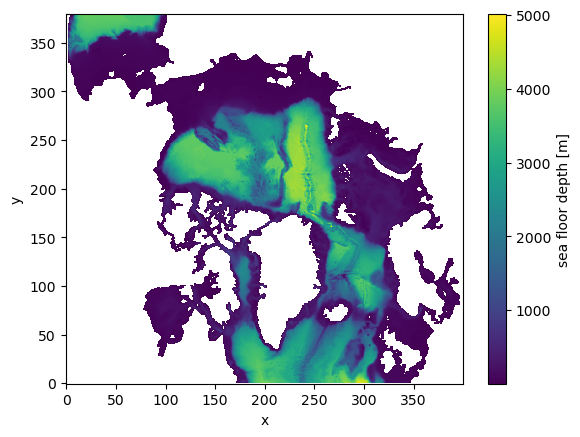

In [6]:
ds_bathy.depth.plot()

In [7]:
land_mask = ds_bathy.depth.isnull()
mask = 1 - land_mask

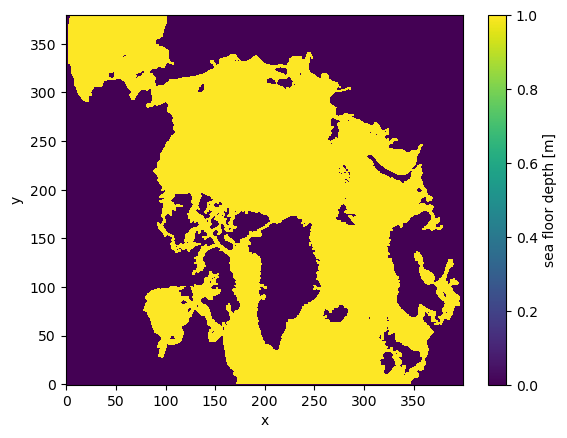

In [8]:
mask.plot()

## Open a single archive file

`open_dataset` auto-detects the file type from the `.b` header and attaches
grid-staggering-appropriate coordinates.

In [9]:
ds = xhycom.open_dataset(DATA_PATH + "archm.2020_001_12", grid=GRID_PATH)
ds

<xarray.Dataset> Size: 3GB
Dimensions:   (time: 1, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time      (time) object 8B 2020-01-01 00:00:00
    lon       (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat       (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u     (y, x) float64 1MB -94.83 -94.67 -94.5 ... 99.16 99.02 98.89
    lat_u     (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v     (y, x) float64 1MB -94.68 -94.52 -94.35 ... 99.0 98.87 98.74
    lat_v     (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
  * k         (k) int64 400B 1 2 3 4 5 6 7 8 9 10 ... 42 43 44 45 46 47 48 49 50
    dens      (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
  * ki        (ki) int64 408B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/79)
    montg1    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    srfhgt    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    oneta     (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surflx    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    wtrflx    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    salflx    (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ...        ...
    CO2_fair  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    CO2_wind  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    ECO_bots  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    surface_  (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_u      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
    si_v      (time, y, x) float64 1MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

## Slice

In [10]:
sst = ds["temp"].isel(k=0, time=0)
sst

<xarray.DataArray 'temp' (y: 380, x: 400)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(380, 400))
Coordinates:
    lon      (y, x) float64 1MB -94.75 -94.58 -94.42 ... 99.09 98.95 98.82
    lat      (y, x) float64 1MB 39.06 39.16 39.26 39.36 ... 56.39 56.29 56.2
    lon_u    (y, x) float64 1MB -94.83 -94.67 -94.5 -94.33 ... 99.16 99.02 98.89
    lat_u    (y, x) float64 1MB 39.01 39.11 39.21 39.31 ... 56.43 56.34 56.25
    lon_v    (y, x) float64 1MB -94.68 -94.52 -94.35 -94.19 ... 99.0 98.87 98.74
    lat_v    (y, x) float64 1MB 38.99 39.09 39.19 39.29 ... 56.43 56.33 56.24
    time     object 8B 2020-01-01 00:00:00
    k        int64 8B 1
    dens     float64 8B 0.1
Dimensions without coordinates: y, x

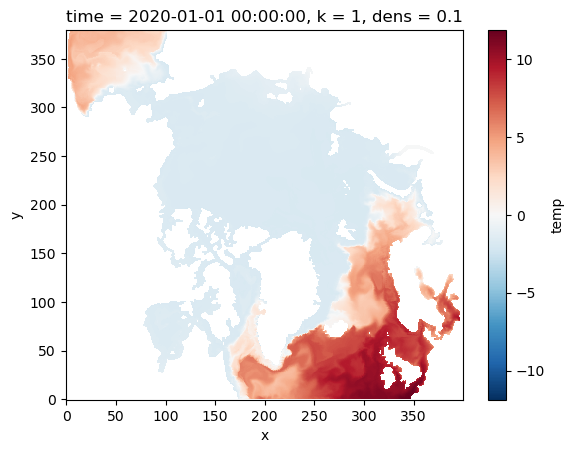

In [11]:
sst.plot()

In [12]:
temp_at_fixed_dens = ds["temp"].isel(time=0).isel(k=13)

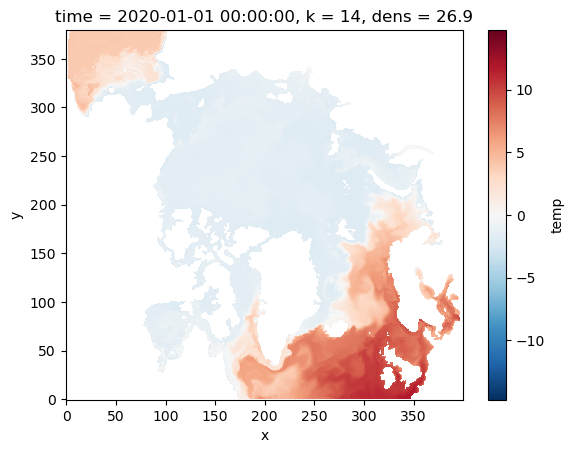

In [13]:
temp_at_fixed_dens.plot()

In [14]:
the_same_temp = ds["temp"].isel(time=0).sel(dens=27.0, method="nearest")

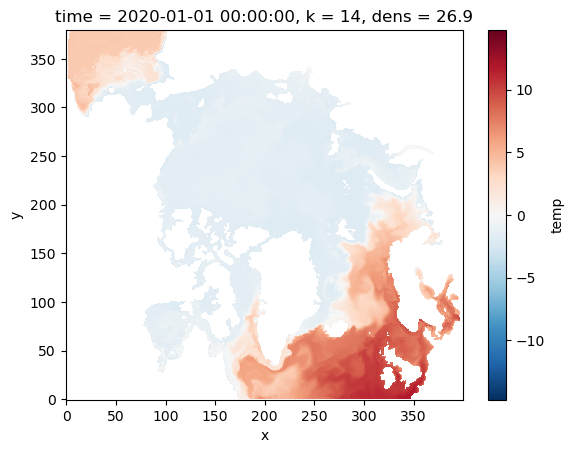

In [15]:
the_same_temp.plot()

## Open a time series

Pass a directory or glob pattern — xhycom finds all `archv.` / `archm.YYYY_DDD_HH.[ab]`
pairs automatically and concatenates them along `time`.
For large datasets, pass `chunks` to enable lazy Dask-backed loading:

In [16]:
ds = xhycom.open_dataset(DATA_PATH + "archm.1993*", grid=GRID_PATH, chunks={"time": 1})

In [17]:
ds

<xarray.Dataset> Size: 1TB
Dimensions:   (time: 365, y: 380, x: 400, k: 50, ki: 51)
Coordinates:
  * time      (time) object 3kB 1993-01-01 00:00:00 ... 1993-12-31 00:00:00
    lon       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat       (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_u     (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_u     (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lon_v     (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
    lat_v     (y, x) float64 1MB dask.array<chunksize=(380, 400), meta=np.ndarray>
  * k         (k) int64 400B 1 2 3 4 5 6 7 8 9 10 ... 42 43 44 45 46 47 48 49 50
    dens      (k) float64 400B dask.array<chunksize=(50,), meta=np.ndarray>
  * ki        (ki) int64 408B 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
Dimensions without coordinates: y, x
Data variables: (12/79)
    montg1    (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    srfhgt    (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    oneta     (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surflx    (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    wtrflx    (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    salflx    (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ...        ...
    CO2_fair  (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    CO2_wind  (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    ECO_bots  (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    surface_  (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_u      (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
    si_v      (time, y, x) float64 444MB dask.array<chunksize=(1, 380, 400), meta=np.ndarray>
Attributes:
    iversn:   23
    iexpt:    28
    yrflag:   3

In [18]:
# Time-mean surface salinity
s_mean = ds["saln"].isel(k=0).mean("time")

KeyError: "No variable named 'saln'. Did you mean one of ('salin', 'salflx')?"

In [ ]:
s_mean.plot()

## Plot

For quick plots, use xarray's in-built plotting.

In [ ]:
sst.plot()

Because `lon` and `lat` are 2-D curvilinear arrays, use `pcolormesh` directly rather than xarray's `.plot()`. U-point and V-point variables carry separate `lon_u`/`lat_u` and `lon_v`/`lat_v` coordinates.

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def nice_plot(ax):

    ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='palegoldenrod')
    #ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
nice_plot(ax)
ax.set_extent((-180, 180, 50, 90), crs=ccrs.PlateCarree())
ax.pcolormesh(sst.lon.values, sst.lat.values, sst.where(mask).values, cmap="RdYlBu_r", transform=ccrs.PlateCarree())

In [ ]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.NorthPolarStereo()})
nice_plot(ax)
ax.set_extent((-180, 180, 50, 90), crs=ccrs.PlateCarree())
ax.pcolormesh(sst.lon.values, sst.lat.values, sst.where(mask).values, cmap="RdYlBu_r", shading='auto', transform=ccrs.PlateCarree())